<a href="https://colab.research.google.com/github/GameLooped/Primero/blob/trabajos/TrabajoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade pip setuptools wheel
!pip uninstall -y lz4
!pip install --no-cache-dir lz4

import lz4.frame
print("LZ4 instalado y cargado correctamente.")


Found existing installation: lz4 4.4.4
Uninstalling lz4-4.4.4:
  Successfully uninstalled lz4-4.4.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s  0:00:00
LZ4 instalado y cargado correctamente.


In [2]:

# 1. INSTALACIÓN DE DEPENDENCIAS

!pip install tensorflow opencv-python-headless pillow matplotlib numpy lz4
!pip install mtcnn  # Para detección de rostros

In [3]:
# 2. IMPORTAR LIBRERÍAS

import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
import base64
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from google.colab import files
import os
from mtcnn import MTCNN

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [4]:
# 3. CREAR MODELO PREENTRENADO SIMPLE

def create_gender_model():
    """
    Crea un modelo simple de clasificación de género
    Nota: En producción usarías un dataset real como CelebA o UTKFace
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')  # 0 = Mujer, 1 = Hombre
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Crear el modelo
model = create_gender_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,569 (9.36 MB)

 Trainable params: 2,453,569 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 4. SIMULAR DATOS DE ENTRENAMIENTO

# Nota: En un caso real, usarías un dataset como UTKFace o CelebA

import numpy as np

def create_synthetic_data(num_samples=1000):
    """
    Crea datos sintéticos para demostración
    En producción, usarías un dataset real
    """
    X = np.random.random((num_samples, 64, 64, 3))
    y = np.random.randint(0, 2, num_samples)  # 0 o 1
    return X, y

print("Creando datos sintéticos para entrenamiento rápido...")
X_train, y_train = create_synthetic_data(1000)
X_val, y_val = create_synthetic_data(200)

# Entrenamiento rápido (solo para demo)
print("Entrenando modelo (esto es solo demostración)...")
history = model.fit(X_train, y_train,
                   epochs=5,
                   batch_size=32,
                   validation_data=(X_val, y_val),
                   verbose=1)

Creando datos sintéticos para entrenamiento rápido...
Entrenando modelo (esto es solo demostración)...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 203ms/step - accuracy: 0.5073 - loss: 0.9181 - val_accuracy: 0.4400 - val_loss: 0.7571
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.5137 - loss: 0.8381 - val_accuracy: 0.4750 - val_loss: 0.7485
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.5395 - loss: 0.8268 - val_accuracy: 0.4450 - val_loss: 0.7389
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.4866 - loss: 0.8167 - val_accuracy: 0.4600 - val_loss: 0.7386
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.5011 - loss: 0.8411 - val_accuracy: 0.5000 - val_loss: 0.7472


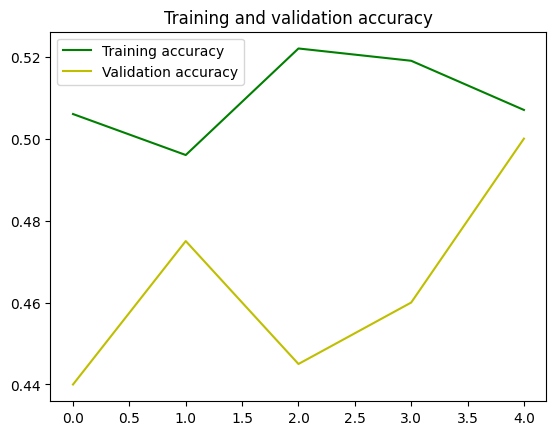

<Figure size 640x480 with 0 Axes>

In [38]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.plot(epochs, acc, 'g', label = "Training accuracy")
plt.plot(epochs, val_acc, 'y', label = "Validation accuracy")
plt.title('Training and validation accuracy')
plt.legend(loc = 0)
plt.figure()
plt.show()

In [6]:
# 5. DETECTOR DE ROSTROS

detector = MTCNN()

def detect_and_extract_face(image):
    """
    Detecta y extrae el rostro de una imagen
    """
    result = detector.detect_faces(image)

    if len(result) > 0:
        # Tomar el primer rostro detectado
        x, y, width, height = result[0]['box']
        face = image[y:y+height, x:x+width]
        # Redimensionar a 64x64 para el modelo
        face = cv2.resize(face, (64, 64))
        return face
    else:
        # Si no se detecta rostro, redimensionar imagen completa
        return cv2.resize(image, (64, 64))


In [14]:
# 6. FUNCIÓN DE PREDICCIÓN

def predict_gender(image):
    """
    Predice el género de una imagen
    """
    # Preprocesar imagen
    if len(image.shape) == 3:
        face = detect_and_extract_face(image)
    else:
        face = cv2.resize(image, (64, 64))

    # Normalizar
    face = face.astype('float32') / 255.0
    face = np.expand_dims(face, axis=0)

    # Predicción
    prediction = model.predict(face)[0][0]

    if prediction < 0.5:
        return "Hombre", prediction
    else:
        return "Mujer", 1 - prediction


In [15]:
# 6.1 FUNCIÓN DE PREDICCIÓN

def predict_gender(image):
    """
    Predice el género de una imagen
    """
    # Preprocesar imagen
    if len(image.shape) == 3:
        face = detect_and_extract_face(image)
    else:
        face = cv2.resize(image, (64, 64))

    # Normalizar
    face = face.astype('float32') / 255.0
    face = np.expand_dims(face, axis=0)

    # Predicción
    prediction = model.predict(face)[0][0]

    if prediction > 0.5:
        return "Hombre", prediction
    else:
        return "Mujer", 1 - prediction

In [9]:

# 7. FUNCIÓN PARA USAR LA CÁMARA WEB

def take_photo_from_camera():
    """
    Captura foto usando la cámara web en Colab
    """
    js = Javascript('''
    async function takePhoto(quality=0.8) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capturar Foto';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)
    data = eval_js('takePhoto()')

    # Decodificar imagen
    binary = base64.b64decode(data.split(',')[1])
    image = Image.open(io.BytesIO(binary))
    image = np.array(image)

    return image

In [10]:
# 8. FUNCIÓN PARA SUBIR ARCHIVOS

def upload_and_predict():
    """
    Permite subir imagen y hacer predicción
    """
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f'Procesando archivo: {filename}')

        # Cargar imagen
        image = Image.open(filename)
        image = np.array(image)

        # Convertir RGB si es necesario
        if len(image.shape) == 3 and image.shape[2] == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Predicción
        gender, confidence = predict_gender(image)

        # Mostrar resultado
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) # Changed to convert BGR to RGB for display
        plt.title(f'Predicción: {gender} (Confianza: {confidence:.2%})')
        plt.axis('off')
        plt.show()

        print(f"Género detectado: {gender}")
        print(f"Nivel de confianza: {confidence:.2%}")

In [11]:
# 9. INTERFAZ PRINCIPAL

def main_menu():
    """
    Menú principal para elegir método de captura
    """
    print("=== CLASIFICADOR DE GÉNERO ===")
    print("Elige una opción:")
    print("1. Usar cámara web")
    print("2. Subir foto desde archivo")
    print("3. Usar imagen de prueba")

    choice = input("Ingresa tu opción (1, 2, o 3): ")

    if choice == "1":
        print("Usando cámara web...")
        image = take_photo_from_camera()
        gender, confidence = predict_gender(image)

        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.title(f'Predicción: {gender} (Confianza: {confidence:.2%})')
        plt.axis('off')
        plt.show()

    elif choice == "2":
        print("Sube tu imagen:")
        upload_and_predict()

    elif choice == "3":
        # Crear imagen de prueba
        test_image = np.random.randint(0, 255, (200, 200, 3), dtype=np.uint8)
        gender, confidence = predict_gender(test_image)

        plt.figure(figsize=(8, 6))
        plt.imshow(test_image)
        plt.title(f'Imagen de Prueba - Predicción: {gender} (Confianza: {confidence:.2%})')
        plt.axis('off')
        plt.show()

    else:
        print("Opción no válida")

In [12]:
# 10. INSTRUCCIONES DE USO

print("=== CLASIFICADOR DE GÉNERO LISTO ===")
print()
print("INSTRUCCIONES:")
print("1. Ejecuta main_menu() para empezar")
print("2. Elige si usar cámara, subir archivo o imagen de prueba")
print("3. El modelo predecirá el género con nivel de confianza")
print()
print("NOTA IMPORTANTE:")
print("Este es un ejemplo educativo. Para uso en producción:")
print("- Usa datasets reales como UTKFace, CelebA, etc.")
print("- Entrena con más épocas y datos")
print("- Considera aspectos éticos y de privacidad")
print()
print("Para empezar, ejecuta: main_menu()")

# ==========================================
# 11. FUNCIÓN ADICIONAL: PROCESAMIENTO POR LOTES
# ==========================================

def batch_predict_folder():
    """
    Procesa múltiples imágenes de una carpeta
    """
    print("Esta función procesaría múltiples imágenes")
    print("Útil para procesar datasets completos")

    # Ejemplo de uso:
    # for filename in os.listdir('path_to_images'):
    #     image = cv2.imread(filename)
    #     gender, conf = predict_gender(image)
    #     print(f"{filename}: {gender} ({conf:.2%})")

print("¡Todo listo! Ejecuta main_menu() para comenzar 🚀")

=== CLASIFICADOR DE GÉNERO LISTO ===

INSTRUCCIONES:
1. Ejecuta main_menu() para empezar
2. Elige si usar cámara, subir archivo o imagen de prueba
3. El modelo predecirá el género con nivel de confianza

NOTA IMPORTANTE:
Este es un ejemplo educativo. Para uso en producción:
- Usa datasets reales como UTKFace, CelebA, etc.
- Entrena con más épocas y datos
- Considera aspectos éticos y de privacidad

Para empezar, ejecuta: main_menu()
¡Todo listo! Ejecuta main_menu() para comenzar 🚀
